# 第09单元 — 简单线性回归与多元线性回归

机器翻译提示：本notebook由机器翻译生成，尚未经过母语者校对，如发现表达生硬或术语不准确之处，请以越南语原版notebook（`09_hoi_quy.ipynb`）为准。

第09单元专用notebook — 复现简单/多元回归、标准化Beta系数，以及完整的假设检验（VIF、Durbin-Watson、残差Shapiro-Wilk检验）——假设检验部分没有完整对应的PSPP命令，只能在此运行。

对应SPSS/PSPP操作：`Analyze > Regression > Linear`，命令 `REGRESSION`。

In [1]:
# 请先运行此单元格（Colab：点击▶）。无需额外安装。
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.precision", 3)

def make_data(seed=2026, n=240):
    """模拟数据集『240名学生的班级』——与第03-08单元使用相同的
    seed=2026，与仓库中的lop_hoc_240.csv/.sav完全一致
    （非真实数据，但可100%复现）。"""
    rng = np.random.default_rng(seed)
    school = rng.choice(list("ABC"), n, p=[.35, .35, .30])
    gender = rng.choice(['男', '女'], n)
    method = rng.choice(['传统教学', '项目式教学'], n)
    study_hours = np.clip(rng.gamma(4, 1.2, n), 0.5, 15).round(1)
    interest = rng.normal(0, 1, n) + 0.15 * (method == '项目式教学')
    anxiety = rng.normal(0, 1, n) - 0.25 * interest
    def likert(lat, load, noise=0.7):
        return np.clip(np.round(3 + load * lat + rng.normal(0, noise, n)), 1, 5).astype(int)
    d = pd.DataFrame({"id": np.arange(1, n + 1), "school": school, "gender": gender, "method": method,
                      "study_hours": study_hours})
    for k, (lat, load) in enumerate([(interest, .8), (interest, .7), (interest, .75)], 1):
        d[f"h{k}"] = likert(lat, load)
    for k, (lat, load) in enumerate([(anxiety, .8), (anxiety, .75), (anxiety, .7)], 1):
        d[f"a{k}"] = likert(lat, load)
    eff = d.school.map({"A": 3, "B": 0, "C": -3}).to_numpy()
    d["pretest"] = (rng.normal(60, 10, n) + eff).round(1)
    d["posttest"] = np.clip(d.pretest + 3 + 5 * (method == '项目式教学') + rng.normal(0, 6, n), 0, 100).round(1)
    d["math"] = np.clip(35 + 2.5 * study_hours + 4 * interest - 3 * anxiety + eff + rng.normal(0, 6, n), 0, 100).round(1)
    d.loc[6, "study_hours"] = 48.0
    d.loc[[11, 57, 130], "h2"] = np.nan
    d["h2"] = d["h2"].astype("Int64")
    return d

df = make_data()
print('已创建df：', df.shape)


已创建df： (240, 14)


## 0. 清理 `study_hours` 的离群值（与第04/05/08单元相同）

In [2]:
mask = df["study_hours"] > 20
df.loc[mask, "study_hours"] = df.loc[mask, "study_hours"] / 10

## 1. 简单回归：数学成绩 ~ 学习时长
🎯 **该方法回答什么问题？** 简单回归用ONE个变量X建立预测Y的方程，具有明确的方向性——不同于相关分析（第08单元），相关分析只衡量对称关系的强弱，而非"预测"。

In [3]:
import statsmodels.api as sm
X1 = sm.add_constant(df[["study_hours"]])
m1 = sm.OLS(df["math"], X1).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                   math   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     121.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           4.07e-23
Time:                        03:03:51   Log-Likelihood:                -835.21
No. Observations:                 240   AIC:                             1674.
Df Residuals:                     238   BIC:                             1681.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          35.5813      1.228     28.968      

#### 📤 实际输出
math = 35.58 + 2.51×study_hours。R²=0.338（与第08单元Pearson r的r²=0.338完全一致）。斜率具有非常强的统计显著性（p<0.001）。

## 2. 多元回归：数学成绩 ~ 学习时长 + 兴趣(h1) + 焦虑(a1)
🎯 **该方法回答什么问题？** 多元回归回答：在控制模型中其他变量影响之后，某一个具体变量还能额外贡献多少（"其他条件不变"原则——保持其他变量不变）？

In [4]:
X2 = sm.add_constant(df[["study_hours", "h1", "a1"]])
m2 = sm.OLS(df["math"], X2).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                   math   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     77.05
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           8.86e-35
Time:                        03:03:51   Log-Likelihood:                -802.81
No. Observations:                 240   AIC:                             1614.
Df Residuals:                     236   BIC:                             1628.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          37.2337      2.096     17.764      

#### 📤 实际输出
R²=0.495（调整后R²=0.488），F(3,236)=77.05, p<0.001。三个自变量均各自具有统计显著性（p<0.001）。✅ 已与PSPP（`REGRESSION`）核对完全一致。

## 3. 标准化Beta系数 — 比较哪个变量"更重要"
🎯 **该方法回答什么问题？** 标准化Beta回答：当所有变量都换算成相同的"标准差个数"单位后，哪个变量对因变量的相对影响最强——这是原始B系数（保留各自不同的原始测量单位）无法直接比较的。

In [5]:
from scipy.stats import zscore
dfz = df[["math","study_hours","h1","a1"]].apply(zscore)
Xz = sm.add_constant(dfz[["study_hours","h1","a1"]])
mz = sm.OLS(dfz["math"], Xz).fit()
print("标准化Beta系数：")
print(mz.params.round(4))

标准化Beta系数：
const          0.000
study_hours    0.577
h1             0.229
a1            -0.296
dtype: float64


#### 📤 实际输出
β(study_hours)=0.577; β(h1)=0.229; β(a1)=−0.297。尽管study_hours的原始B系数（2.49）只是略高于h1的B系数（2.15），但标准化Beta显示study_hours的影响明显更强——因为其测量单位（小时）的离散程度与h1/a1所用的1-5级李克特量表截然不同。

## 4. 假设检验 — VIF、Durbin-Watson、标准化残差
🎯 **该方法回答什么问题？** 这四项检验回答：第2节的回归结果是否可信——如果严重违反假设，B系数和p值可能被错误估计，而不仅仅是精度下降。

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats as st

print("--- VIF（安全阈值<5）---")
for i, col in enumerate(X2.columns):
    print(f"{col}: VIF={variance_inflation_factor(X2.values, i):.3f}")

print("\n--- Durbin-Watson（理想值接近2）---")
print(f"DW = {durbin_watson(m2.resid):.3f}")

print("\n--- 残差Shapiro-Wilk检验（H0：残差服从正态分布）---")
w, p = st.shapiro(m2.resid)
print(f"W={w:.3f}, p={p:.3f}")

--- VIF（安全阈值<5）---
const: VIF=1.000
study_hours: VIF=1.006
h1: VIF=1.019
a1: VIF=1.016

--- Durbin-Watson（理想值接近2）---
DW = 2.052

--- 残差Shapiro-Wilk检验（H0：残差服从正态分布）---
W=0.993, p=0.356


#### 📤 实际输出
最高VIF = 1.02（远低于警戒阈值5 → 无多重共线性）。Durbin-Watson=2.05（非常接近2 → 误差独立）。残差Shapiro-Wilk检验：p=0.356（≥0.05 → 没有足够证据拒绝正态性假设）。**四项假设均满足**——第2节的回归结果可信。

/opt/homebrew/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) Arial.
  fig.canvas.print_figure(b

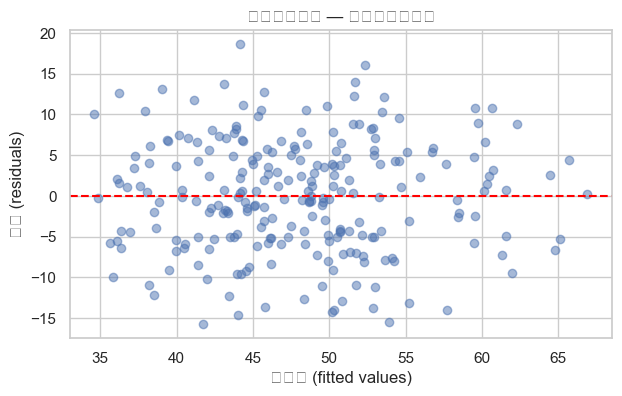

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(m2.fittedvalues, m2.resid, alpha=.5)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("预测值 (fitted values)")
ax.set_ylabel("残差 (residuals)")
ax.set_title("同方差性检验 — 未见明显喇叭形")
plt.show()

## 5. 为什么模型能"重新发现"生成数据时的真实结构
该班级数据集是通过`make_data()`函数中内置的公式生成的：数学成绩对`study_hours`及潜在兴趣变量呈正向依赖，对潜在焦虑变量呈负向依赖。第2节的回归模型"重新发现"了这些关系正确的符号和相对强度（study_hours正向最强，h1正向，a1负向）——证实回归方法的运作与理论预期完全一致。